# Manipulations d'images

In [1]:
import os
import numpy as np
from PIL import ImageOps, Image, ImageDraw

In [2]:
DataPath = "/Users/me/Documents/Work/Dev/_data/imagenet-sample-images-master"
ImageFile = "n02391049_zebra.JPEG"
filename = os.path.join(DataPath, ImageFile)
left, top, right, bottom = 325, 150, 365, 190 # zone entourant l'oeil du zèbre

## Import with PIL

> Attention : utilisation d'un répertoire de données en dehors de l'environnement do notebook !

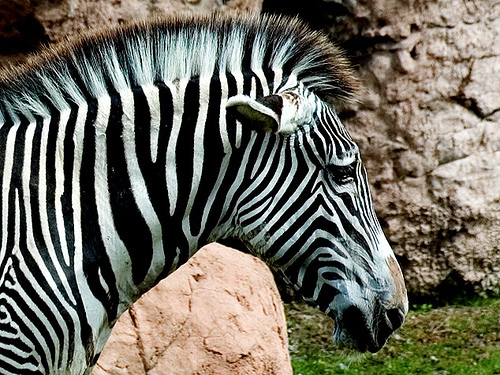

In [3]:
input_image = Image.open(filename)
input_image

In [4]:
print(input_image.size)
print(type(input_image.size))

(500, 375)
<class 'tuple'>


## PIL to NP

In [5]:
numpy_array = np.array(input_image)
print(numpy_array.shape)

(375, 500, 3)


In [6]:
numpy_array

array([[[ 57,  43,  17],
        [ 33,  15,   0],
        [ 43,  19,   7],
        ...,
        [180, 174, 160],
        [197, 191, 177],
        [191, 185, 171]],

       [[ 33,  14,   0],
        [ 45,  21,   9],
        [ 41,  14,   3],
        ...,
        [179, 167, 151],
        [190, 178, 162],
        [181, 169, 153]],

       [[ 43,  18,  14],
        [ 28,   0,   0],
        [ 38,   9,   1],
        ...,
        [171, 154, 136],
        [155, 138, 120],
        [142, 125, 107]],

       ...,

       [[ 44,  49,  45],
        [154, 159, 153],
        [176, 183, 175],
        ...,
        [ 18,  38,   3],
        [ 33,  56,   2],
        [ 30,  55,   0]],

       [[  1,   1,   0],
        [ 22,  23,  18],
        [ 71,  74,  67],
        ...,
        [  8,  29,   0],
        [ 23,  47,   0],
        [ 31,  56,   0]],

       [[  2,   0,   1],
        [  0,   0,   0],
        [  3,   4,   0],
        ...,
        [ 75,  99,  47],
        [ 90, 115,  58],
        [ 96, 121,  63]]

## NP to PIL

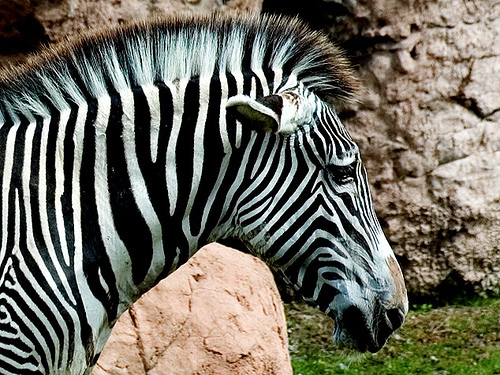

In [7]:
im = Image.fromarray(numpy_array)
im

## Crop with PIL

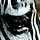

In [8]:
im1 = im.crop((left, top, right, bottom))
im1

## Import with PyTorch

In [9]:
import torch
from torchvision import transforms as T
#from torchvision.io import read_image
from torchvision.io import decode_image

Dimensions (C, H, W) torch.Size([3, 375, 500]) 
Valeur min: 0 
Valeur max: 255


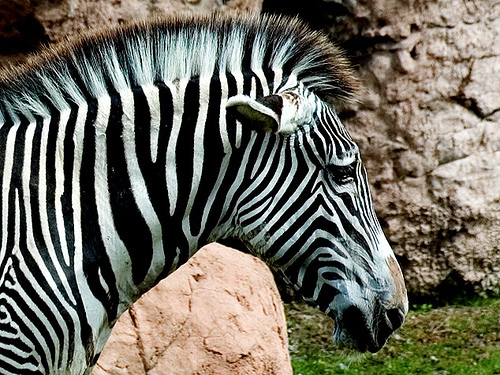

In [10]:
img1_t = decode_image(filename)
print("Dimensions (C, H, W)", img1_t.size(), "\nValeur min:", img1_t.min().item(), "\nValeur max:", img1_t.max().item())
img1 = T.functional.to_pil_image(img1_t)
display(img1)

Les 50 premières lignes sont noircies.

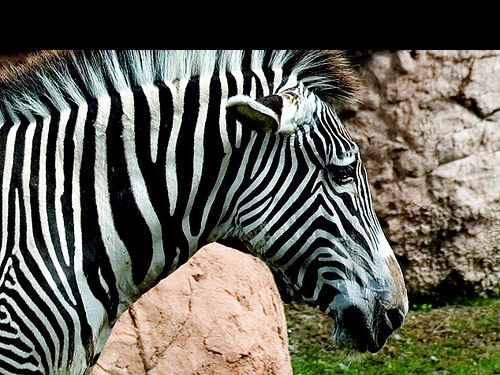

In [11]:
img2_t = img1_t.clone()
img2_t[:, 0:50, :] = 0.
img1 = T.functional.to_pil_image(img2_t)
display(img1)

Les pixels correspondant à l'oeil sont noircis

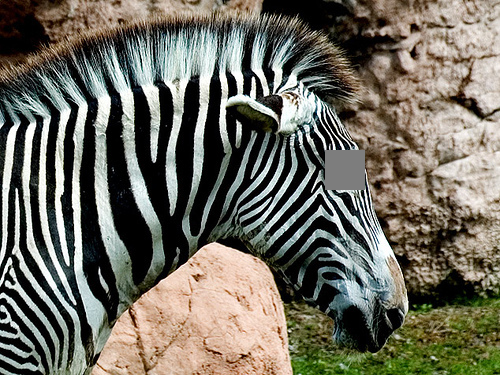

In [12]:
img2_t = img1_t.clone()
img2_t[:, top:bottom, left:right] = 125
img1 = T.functional.to_pil_image(img2_t)
display(img1)

Preuve de la correspondance croisée entre (X, Y) et (H, W) ou (R, C) : X <-> C et Y <-> R

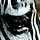

In [13]:
# Tensor space
crop_t = img1_t[:, top:bottom, left:right] # (Ch, R, C)
crop = T.functional.to_pil_image(crop_t)
# PIL space
display(crop)

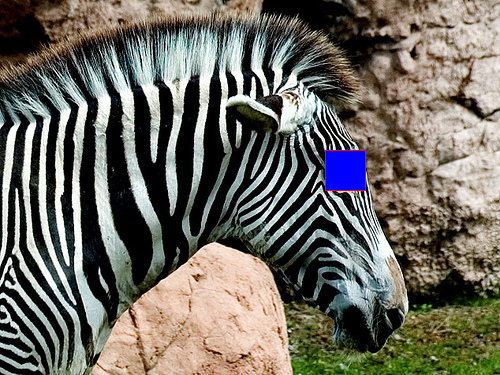

In [14]:
img1_pil = T.functional.to_pil_image(img1_t)
img_draw = ImageDraw.Draw(img1_pil)

# PIL space
img_draw.rectangle([(left, top), (right, bottom)], fill ="blue", outline ="red")
display(img1_pil)